🔍 INVESTIGASI DATA .mseed GEMPA MERUSAK

📂 Membaca direktori: /Volumes/Extreme SSD/unduhan_waveform_major_earthquakes
✅ Total file .mseed valid: 17

📊 Ekstrak metadata dari nama file...
✅ Metadata diekstrak dari 17 file

📋 DAFTAR FILE GEMPA MERUSAK

Total file: 17
Event unik: 17
Stasiun unik: 14
Jaringan unik: 2

📋 Detail file:
--------------------------------------------------------------------------------
  Pangandaran_2006     | M7.7 | Tsunami.Pangandaran | ?
  Aceh_2004            | M9.1 | Tsunami.Aceh   | ?
  Bengkulu_2007        | M8.5 | Gempa.Bengkulu | ?
  Padang_2009          | M7.6 | Gempa.Padang | ?
  Sumatra_2010         | M7.7 | Gempa.Sumatra | ?
  Nias_2005            | M8.6 | Gempa.Nias   | ?
  Yogyakarta_2006      | M6.3 | Gempa.Yogyakarta | ?
  Pidie_Jaya_2016      | M6.5 | Gempa.Pidie  | ?
  Mentawai_2010        | M7.7 | Tsunami.Mentawai | ?
  Aceh_2012            | M8.6 | Gempa.Aceh   | ?
  Maluku_2019          | M7.3 | Gempa.Maluku | ?
  Mamuju_2021          | M7.0 

Hitung SNR: 100%|██████████| 17/17 [00:00<00:00, 277.40it/s]


✅ SNR dihitung untuk 17 file

📊 Statistik SNR:
  Min: 2.50 dB
  Max: 57.20 dB
  Mean: 24.45 dB
  Median: 17.51 dB

🔝 TOP 5 SNR TERTINGGI:
  Pidie_Jaya_2016      | LHMI   | SNR: 57.20 dB
  Yogyakarta_2006      | YOGI   | SNR: 53.23 dB
  Padang_2009          | BKNI   | SNR: 50.85 dB
  Sumatra_2010         | GSI    | SNR: 48.17 dB
  Maluku_2023          | TNTI   | SNR: 43.90 dB

🔻 TOP 5 SNR TERENDAH:
  Bengkulu_2007        | MNAI   | SNR: 2.50 dB
  Nias_2005            | UGM    | SNR: 2.75 dB
  Mamuju_2021          | BKB    | SNR: 5.43 dB
  Palu_2018            | TOLI2  | SNR: 6.53 dB
  Aceh_2012            | GSI    | SNR: 6.82 dB

📊 Membuat plot waveform untuk 5 event terbaik...
  Error plotting Pidie_Jaya_2016: name 'signal' is not defined
  ✅ Plot: Pidie_Jaya_2016
  Error plotting Yogyakarta_2006: name 'signal' is not defined
  ✅ Plot: Yogyakarta_2006
  Error plotting Padang_2009: name 'signal' is not defined
  ✅ Plot: Padang_2009
  Error plotting Sumatra_2010: name 'signal' is not de


✅ Hasil tersimpan di folder: investigasi_major/


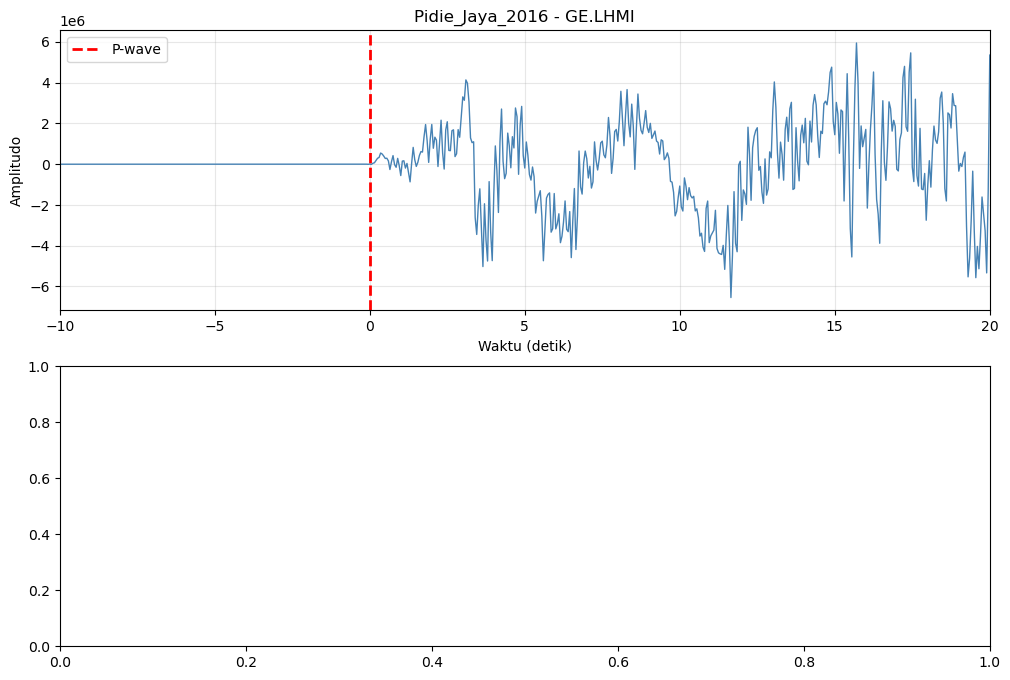

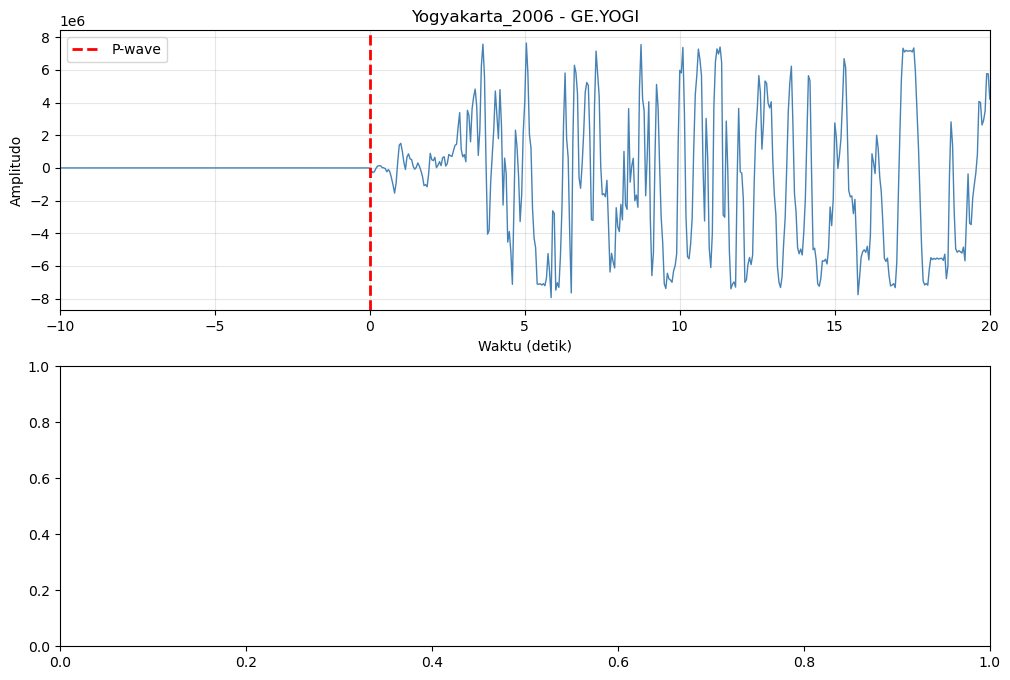

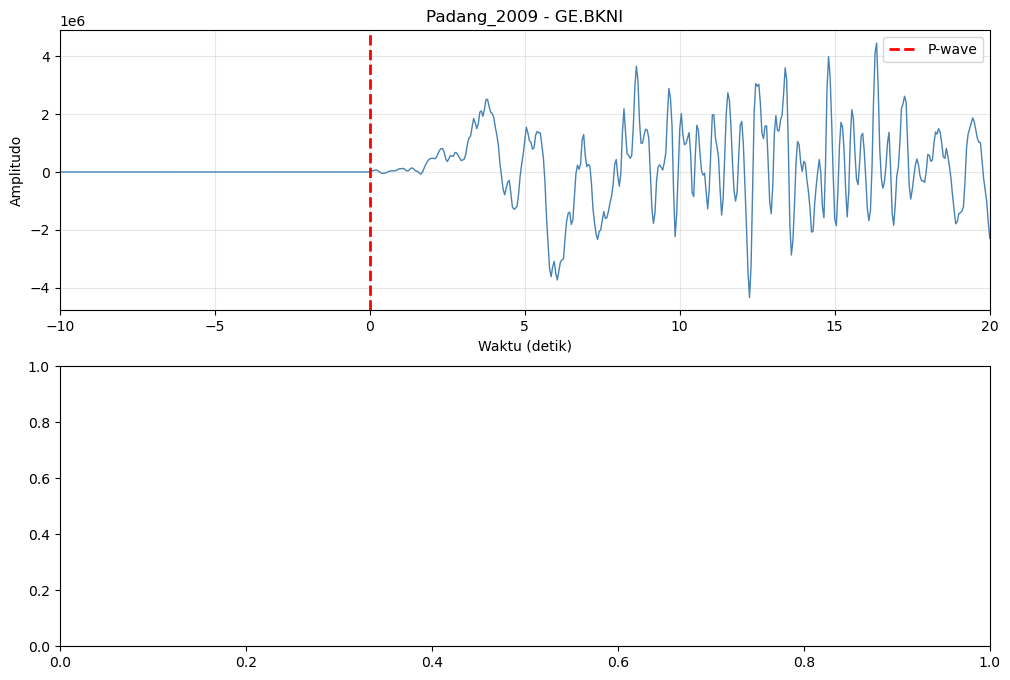

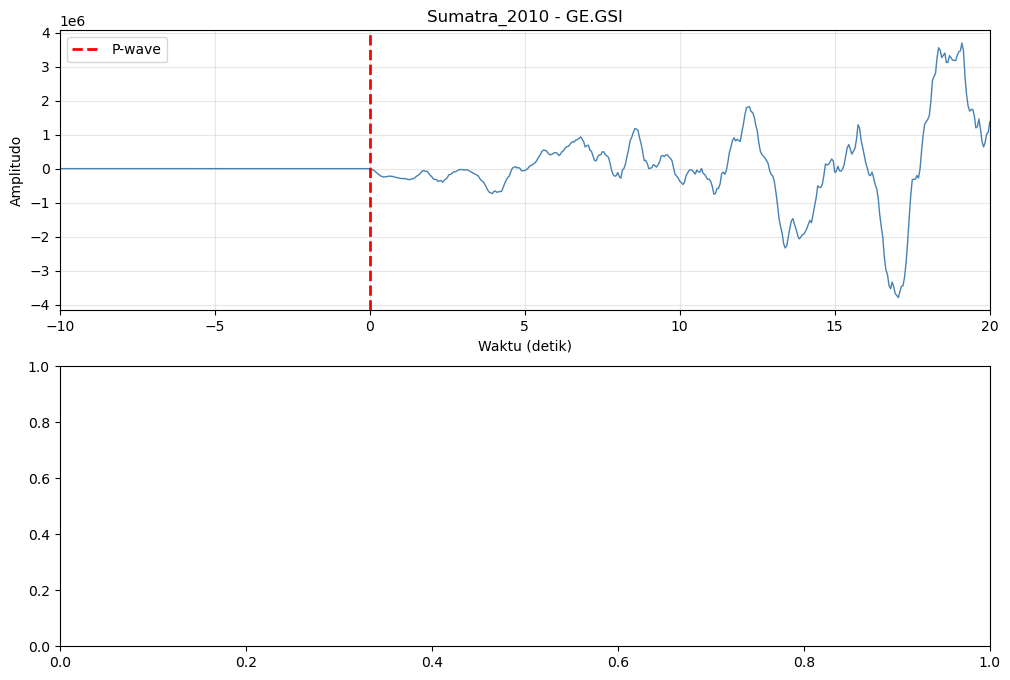

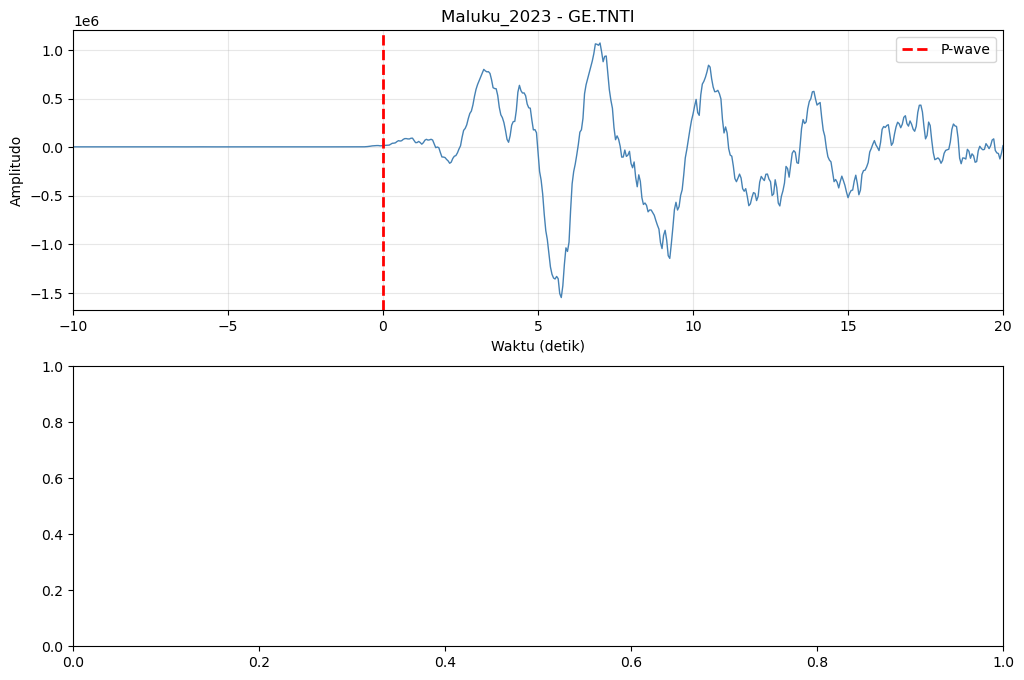

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
INVESTIGASI DATA .mseed GEMPA MERUSAK INDONESIA
- Daftar file
- Metadata dari nama file
- Komponen yang tersedia (Z, N, E)
- SNR dan kualitas sinyal
"""

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from obspy import read, UTCDateTime
from obspy.signal.trigger import recursive_sta_lta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

WAVEFORM_DIR = "/Volumes/Extreme SSD/unduhan_waveform_major_earthquakes"
OUTPUT_DIR = "investigasi_major"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# Daftar gempa merusak untuk referensi
MAJOR_EARTHQUAKES = {
    "Aceh_2004": {"date": "20041226", "mag": 9.1},
    "Nias_2005": {"date": "20050328", "mag": 8.6},
    "Yogyakarta_2006": {"date": "20060527", "mag": 6.3},
    "Pangandaran_2006": {"date": "20060717", "mag": 7.7},
    "Bengkulu_2007": {"date": "20070912", "mag": 8.5},
    "Padang_2009": {"date": "20090930", "mag": 7.6},
    "Sumatra_2010": {"date": "20100406", "mag": 7.7},
    "Mentawai_2010": {"date": "20101025", "mag": 7.7},
    "Aceh_2012": {"date": "20120411", "mag": 8.6},
    "Papua_2013": {"date": "20130406", "mag": 7.2},
    "Pidie_Jaya_2016": {"date": "20161207", "mag": 6.5},
    "Lombok_2018": {"date": "20180805", "mag": 7.0},
    "Palu_2018": {"date": "20180928", "mag": 7.5},
    "Maluku_2019": {"date": "20190714", "mag": 7.3},
    "Mamuju_2021": {"date": "20210114", "mag": 7.0},
    "Cianjur_2022": {"date": "20221121", "mag": 5.6},
    "Maluku_2023": {"date": "20230118", "mag": 7.2},
    "Maluku_2024": {"date": "20240108", "mag": 7.0},
}

# Parameter SNR
SAMPLE_RATE = 100.0
SIG_DURATION = 7.0
NOISE_DURATION = 7.0
NORM_WINDOW = 9.0
STA_WIN = 1.0
LTA_WIN = 10.0
TRIGGER_THRESHOLD = 3.5

# =============================================
# 2. BACA FILE
# =============================================

print("="*70)
print("🔍 INVESTIGASI DATA .mseed GEMPA MERUSAK")
print("="*70)

print(f"\n📂 Membaca direktori: {WAVEFORM_DIR}")
files = list(Path(WAVEFORM_DIR).glob("*.mseed"))
# Filter file ._ (macOS metadata)
files = [f for f in files if not f.name.startswith('._')]

print(f"✅ Total file .mseed valid: {len(files)}")

if len(files) == 0:
    print("❌ Tidak ada file .mseed ditemukan!")
    exit()

# =============================================
# 3. EKSTRAK METADATA DARI NAMA FILE
# =============================================

print("\n📊 Ekstrak metadata dari nama file...")

def parse_filename(filename):
    """Ekstrak metadata dari nama file."""
    stem = filename.stem
    parts = stem.split('_')
    
    # Coba ekstrak network dan station
    network = parts[0] if len(parts) > 0 else 'UNK'
    station = parts[1] if len(parts) > 1 else 'UNK'
    
    # Cari timestamp (8 digit atau 14 digit)
    timestamps = re.findall(r'\b(\d{8})\b', stem)
    full_timestamps = re.findall(r'\b(\d{14})\b', stem)
    
    date_str = timestamps[0] if timestamps else None
    full_date_str = full_timestamps[0] if full_timestamps else None
    
    # Cari nama gempa
    event_name = None
    for name in MAJOR_EARTHQUAKES.keys():
        if name.lower() in stem.lower():
            event_name = name
            break
    
    return {
        'file': filename.name,
        'network': network,
        'station': station,
        'date_str': date_str,
        'full_date_str': full_date_str,
        'event_name': event_name,
        'magnitude': MAJOR_EARTHQUAKES.get(event_name, {}).get('mag') if event_name else None
    }

metadata = []
for f in files:
    meta = parse_filename(f)
    metadata.append(meta)

df_meta = pd.DataFrame(metadata)
print(f"✅ Metadata diekstrak dari {len(df_meta)} file")

# =============================================
# 4. TAMPILKAN DAFTAR FILE
# =============================================

print("\n" + "="*70)
print("📋 DAFTAR FILE GEMPA MERUSAK")
print("="*70)

print(f"\nTotal file: {len(df_meta)}")
print(f"Event unik: {df_meta['event_name'].nunique()}")
print(f"Stasiun unik: {df_meta['station'].nunique()}")
print(f"Jaringan unik: {df_meta['network'].nunique()}")

print("\n📋 Detail file:")
print("-"*80)
for _, row in df_meta.iterrows():
    name = row['event_name'] or 'Unknown'
    mag = row['magnitude'] or '?'
    station = row['station']
    network = row['network']
    date = row['date_str'] or '?'
    print(f"  {name:20} | M{mag:.1f} | {network}.{station:6} | {date}")

# =============================================
# 5. CEK KOMPONEN
# =============================================

print("\n" + "="*70)
print("📊 CEK KOMPONEN (Z, N, E)")
print("="*70)

def check_components(file_path):
    """Cek komponen yang tersedia dalam file .mseed."""
    try:
        st = read(str(file_path))
        channels = [tr.stats.channel for tr in st]
        has_z = any(ch.endswith('Z') for ch in channels)
        has_n = any(ch.endswith('N') for ch in channels)
        has_e = any(ch.endswith('E') for ch in channels)
        return {
            'has_z': has_z,
            'has_n': has_n,
            'has_e': has_e,
            'channels': channels,
            'n_traces': len(st)
        }
    except Exception as e:
        return {
            'has_z': False,
            'has_n': False,
            'has_e': False,
            'channels': [],
            'n_traces': 0,
            'error': str(e)
        }

component_data = []
for f in files:
    comp = check_components(f)
    comp['file'] = f.name
    component_data.append(comp)

df_comp = pd.DataFrame(component_data)

print(f"\n✅ File dengan komponen Z: {df_comp['has_z'].sum()}/{len(df_comp)}")
print(f"✅ File dengan komponen N: {df_comp['has_n'].sum()}/{len(df_comp)}")
print(f"✅ File dengan komponen E: {df_comp['has_e'].sum()}/{len(df_comp)}")

# File tanpa Z
no_z = df_comp[~df_comp['has_z']]
if len(no_z) > 0:
    print(f"\n⚠️ {len(no_z)} file TANPA komponen Z:")
    for _, row in no_z.iterrows():
        print(f"  - {row['file']} (channels: {row['channels']})")

# =============================================
# 6. FUNGSI SNR
# =============================================

def pick_p_arrival(trace):
    """Deteksi P-wave dengan STA/LTA."""
    try:
        sr = trace.stats.sampling_rate
        sta_n = int(STA_WIN * sr)
        lta_n = int(LTA_WIN * sr)
        
        if len(trace.data) < lta_n + sta_n:
            return trace.stats.starttime + 5.0
        
        cft = recursive_sta_lta(trace.data, sta_n, lta_n)
        trigger_indices = np.where(cft > TRIGGER_THRESHOLD)[0]
        
        if len(trigger_indices) > 0:
            pick_idx = trigger_indices[0]
            if pick_idx > int(2 * sr):
                return trace.stats.starttime + pick_idx / sr
        
        max_idx = np.argmax(np.abs(trace.data))
        if max_idx > 0:
            return trace.stats.starttime + max_idx / sr
    except:
        pass
    return trace.stats.starttime + 5.0

def calculate_snr(trace, p_time):
    """Hitung SNR dari trace dan waktu P."""
    try:
        sr = trace.stats.sampling_rate
        
        # Signal: 7 detik setelah P
        sig_start = p_time
        sig_end = p_time + SIG_DURATION
        tr_signal = trace.copy().trim(sig_start, sig_end)
        
        # Noise: 7 detik sebelum P
        noise_start = p_time - NOISE_DURATION
        noise_end = p_time
        tr_noise = trace.copy().trim(noise_start, noise_end)
        
        if len(tr_signal.data) == 0 or len(tr_noise.data) == 0:
            return None, None
        
        # Resample ke 100 Hz
        if tr_signal.stats.sampling_rate != SAMPLE_RATE:
            tr_signal.resample(SAMPLE_RATE)
        if tr_noise.stats.sampling_rate != SAMPLE_RATE:
            tr_noise.resample(SAMPLE_RATE)
        
        # Detrend
        tr_signal.detrend('simple')
        tr_noise.detrend('simple')
        
        # Hitung SNR
        rms_signal = np.sqrt(np.mean(tr_signal.data**2))
        rms_noise = np.sqrt(np.mean(tr_noise.data**2))
        
        if rms_noise == 0:
            return float('inf'), float('inf')
        
        snr_linear = rms_signal / rms_noise
        snr_db = 20 * np.log10(snr_linear + 1e-10)
        
        return snr_db, snr_linear
    except Exception as e:
        return None, None

# =============================================
# 7. HITUNG SNR UNTUK FILE DENGAN Z
# =============================================

print("\n" + "="*70)
print("📊 ANALISIS SNR")
print("="*70)

snr_data = []
for f in tqdm(files, desc="Hitung SNR"):
    try:
        st = read(str(f))
        # Ambil trace Z
        trace_z = None
        for tr in st:
            if tr.stats.channel.endswith('Z'):
                trace_z = tr
                break
        if trace_z is None:
            continue
        
        p_time = pick_p_arrival(trace_z)
        snr_db, snr_linear = calculate_snr(trace_z, p_time)
        
        if snr_db is not None:
            # Cari event name
            event_name = None
            for name in MAJOR_EARTHQUAKES.keys():
                if name.lower() in f.name.lower():
                    event_name = name
                    break
            
            snr_data.append({
                'file': f.name,
                'event': event_name or 'Unknown',
                'station': trace_z.stats.station,
                'network': trace_z.stats.network,
                'snr_db': snr_db,
                'snr_linear': snr_linear,
                'p_arrival': str(p_time),
                'channel': trace_z.stats.channel
            })
    except Exception as e:
        continue

df_snr = pd.DataFrame(snr_data)
print(f"\n✅ SNR dihitung untuk {len(df_snr)} file")

if len(df_snr) > 0:
    print("\n📊 Statistik SNR:")
    print(f"  Min: {df_snr['snr_db'].min():.2f} dB")
    print(f"  Max: {df_snr['snr_db'].max():.2f} dB")
    print(f"  Mean: {df_snr['snr_db'].mean():.2f} dB")
    print(f"  Median: {df_snr['snr_db'].median():.2f} dB")
    
    print("\n🔝 TOP 5 SNR TERTINGGI:")
    for _, row in df_snr.nlargest(5, 'snr_db').iterrows():
        print(f"  {row['event']:20} | {row['station']:6} | SNR: {row['snr_db']:.2f} dB")
    
    print("\n🔻 TOP 5 SNR TERENDAH:")
    for _, row in df_snr.nsmallest(5, 'snr_db').iterrows():
        print(f"  {row['event']:20} | {row['station']:6} | SNR: {row['snr_db']:.2f} dB")

# =============================================
# 8. PLOT SAMPLE
# =============================================

print("\n📊 Membuat plot waveform untuk 5 event terbaik...")

def plot_waveform(file_path, event_name, output_dir):
    """Plot waveform dan spektogram untuk satu file."""
    try:
        st = read(str(file_path))
        trace_z = None
        for tr in st:
            if tr.stats.channel.endswith('Z'):
                trace_z = tr
                break
        if trace_z is None:
            return
        
        p_time = pick_p_arrival(trace_z)
        sr = trace_z.stats.sampling_rate
        
        # Potong sinyal 30 detik
        start = p_time - 10
        end = p_time + 20
        tr_plot = trace_z.copy().trim(start, end)
        
        if len(tr_plot.data) == 0:
            return
        
        time_axis = np.linspace(-10, 20, len(tr_plot.data))
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        # Waveform
        ax1.plot(time_axis, tr_plot.data, color='steelblue', linewidth=1)
        ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='P-wave')
        ax1.set_xlabel('Waktu (detik)')
        ax1.set_ylabel('Amplitudo')
        ax1.set_title(f'{event_name} - {trace_z.stats.network}.{trace_z.stats.station}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(-10, 20)
        
        # Spektogram
        f, t, Sxx = signal.spectrogram(tr_plot.data, fs=sr, nperseg=128, noverlap=64)
        ax2.pcolormesh(t - 10, f, 10 * np.log10(Sxx + 1e-10), cmap='viridis', shading='gouraud')
        ax2.set_xlabel('Waktu (detik)')
        ax2.set_ylabel('Frekuensi (Hz)')
        ax2.set_title('Spektogram')
        ax2.set_ylim(0, 25)
        ax2.axvline(0, color='red', linestyle='--', linewidth=1)
        
        plt.tight_layout()
        plt.savefig(f"{output_dir}/waveform_{event_name}.png", dpi=150, bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"  Error plotting {event_name}: {e}")

if len(df_snr) > 0:
    # Ambil 5 event dengan SNR tertinggi
    top_events = df_snr.nlargest(5, 'snr_db')
    for _, row in top_events.iterrows():
        file_path = Path(WAVEFORM_DIR) / row['file']
        event_name = row['event'].replace(' ', '_')
        plot_waveform(file_path, event_name, OUTPUT_DIR)
        print(f"  ✅ Plot: {event_name}")

# =============================================
# 9. SIMPAN HASIL
# =============================================

df_meta.to_csv(f"{OUTPUT_DIR}/file_metadata.csv", index=False)
df_comp.to_csv(f"{OUTPUT_DIR}/component_analysis.csv", index=False)
if len(df_snr) > 0:
    df_snr.to_csv(f"{OUTPUT_DIR}/snr_analysis.csv", index=False)

print(f"\n✅ Hasil tersimpan di folder: {OUTPUT_DIR}/")
print("="*70)

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
LIST FILE .mseed DI FOLDER GEMPA MERUSAK
"""

import os
from pathlib import Path

WAVEFORM_DIR = "/Volumes/Extreme SSD/unduhan_waveform_major_earthquakes"

print("="*70)
print("📂 DAFTAR FILE .mseed DI FOLDER GEMPA MERUSAK")
print("="*70)

if not os.path.exists(WAVEFORM_DIR):
    print(f"❌ Folder tidak ditemukan: {WAVEFORM_DIR}")
    exit()

files = list(Path(WAVEFORM_DIR).glob("*.mseed"))
files = [f for f in files if not f.name.startswith('._')]

print(f"\n✅ Total file .mseed: {len(files)}")
print("\n📋 DAFTAR FILE:")
print("-"*70)

for f in sorted(files):
    size = f.stat().st_size / 1024  # KB
    print(f"  {f.name:60} | {size:8.1f} KB")

📂 DAFTAR FILE .mseed DI FOLDER GEMPA MERUSAK

✅ Total file .mseed: 17

📋 DAFTAR FILE:
----------------------------------------------------------------------
  Gempa_Aceh_2012_GE_GSI_BMKG-20120411090054-001.mseed         |     79.5 KB
  Gempa_Bengkulu_2007_GE_MNAI_official20070912111026830_34.mseed |    490.5 KB
  Gempa_Cianjur_2022_GE_BBJI_BMKG-20221121062111-001.mseed     |     52.5 KB
  Gempa_Lombok_2018_GE_PLAI_BMKG-20180805204133-001.mseed      |     38.5 KB
  Gempa_Maluku_2019_GE_TNTI_BMKG-20190714091051-001.mseed      |     81.5 KB
  Gempa_Maluku_2023_GE_TNTI_BMKG-20230118060616-001.mseed      |     75.5 KB
  Gempa_Maluku_2024_GE_TNTI_BMKG-20240108204847-001.mseed      |     58.0 KB
  Gempa_Mamuju_2021_GE_BKB_BMKG-20210114183219-001.mseed       |     64.0 KB
  Gempa_Nias_2005_GE_UGM_official20050328160936530_30.mseed    |     96.0 KB
  Gempa_Padang_2009_GE_BKNI_BMKG-20090930101610-001.mseed      |    442.5 KB
  Gempa_Pidie_Jaya_2016_GE_LHMI_BMKG-20161206220334-001.mseed  |     86

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
EKSTRAKSI 17 FILE .mseed GEMPA MERUSAK KE JSON
"""

import os
import json
import numpy as np
from pathlib import Path
from obspy import read
from obspy.signal.trigger import recursive_sta_lta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

WAVEFORM_DIR = "/Volumes/Extreme SSD/unduhan_waveform_major_earthquakes"
OUTPUT_JSON = "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json"

# Parameter MCU-Quake
SAMPLE_RATE = 100.0
SIG_DURATION = 7.0
NOISE_DURATION = 7.0
NORM_WINDOW = 9.0
STA_WIN = 1.0
LTA_WIN = 10.0
TRIGGER_THRESHOLD = 3.5

def pick_p_arrival(trace):
    try:
        sr = trace.stats.sampling_rate
        sta_n = int(STA_WIN * sr)
        lta_n = int(LTA_WIN * sr)
        if len(trace.data) < lta_n + sta_n:
            return trace.stats.starttime + 5.0
        cft = recursive_sta_lta(trace.data, sta_n, lta_n)
        trigger_indices = np.where(cft > TRIGGER_THRESHOLD)[0]
        if len(trigger_indices) > 0:
            pick_idx = trigger_indices[0]
            if pick_idx > int(2 * sr):
                return trace.stats.starttime + pick_idx / sr
        max_idx = np.argmax(np.abs(trace.data))
        if max_idx > 0:
            return trace.stats.starttime + max_idx / sr
    except:
        pass
    return trace.stats.starttime + 5.0

def extract_windows(trace, p_time):
    try:
        tr_signal = trace.copy().trim(p_time, p_time + SIG_DURATION)
        tr_noise = trace.copy().trim(p_time - NOISE_DURATION, p_time)
        tr_signal.detrend('simple')
        tr_noise.detrend('simple')
        if tr_signal.stats.sampling_rate != SAMPLE_RATE:
            tr_signal.resample(SAMPLE_RATE)
        if tr_noise.stats.sampling_rate != SAMPLE_RATE:
            tr_noise.resample(SAMPLE_RATE)
        tr_norm = trace.copy().trim(p_time, p_time + NORM_WINDOW)
        if len(tr_norm.data) > 0:
            max_val = np.max(np.abs(tr_norm.data))
        else:
            max_val = np.max(np.abs(tr_signal.data))
        if np.isnan(max_val) or max_val < 1e-6:
            max_val = 1.0
        signal_data = tr_signal.data / max_val
        noise_data = tr_noise.data / max_val
        target_len = int(SAMPLE_RATE * SIG_DURATION)
        def fix_length(data):
            if len(data) > target_len:
                return data[:target_len]
            elif len(data) < target_len:
                return np.pad(data, (0, target_len - len(data)), 'constant')
            return data
        return fix_length(signal_data).tolist(), fix_length(noise_data).tolist()
    except:
        return None, None

print("="*60)
print("🚀 EKSTRAKSI GEMPA MERUSAK KE JSON")
print("="*60)

files = list(Path(WAVEFORM_DIR).glob("*.mseed"))
files = [f for f in files if not f.name.startswith('._')]
print(f"📁 Ditemukan {len(files)} file")

# Load JSON existing
if os.path.exists(OUTPUT_JSON):
    with open(OUTPUT_JSON, 'r') as f:
        existing_data = json.load(f)
    print(f"📂 Load JSON existing: {len(existing_data)} entries")
else:
    existing_data = {}

success = 0
failed = 0

for f in tqdm(files, desc="Ekstraksi"):
    try:
        st = read(str(f))
        trace_z = None
        for tr in st:
            if tr.stats.channel.endswith('Z'):
                trace_z = tr
                break
        if trace_z is None:
            failed += 1
            continue
        
        p_time = pick_p_arrival(trace_z)
        signal, noise = extract_windows(trace_z, p_time)
        if signal is None:
            failed += 1
            continue
        
        key = f.stem
        existing_data[key] = {
            'type': 'se',
            'Z': signal,
            'Z_noise': noise,
            'metadata': {
                'network': trace_z.stats.network,
                'station': trace_z.stats.station,
                'p_arrival': str(p_time),
                'file': f.name
            }
        }
        success += 1
    except Exception as e:
        failed += 1
        print(f"Error: {f.name} - {e}")

# Simpan
with open(OUTPUT_JSON, 'w') as f:
    json.dump(existing_data, f, indent=2)

print(f"\n✨ SELESAI! Berhasil: {success}, Gagal: {failed}")
print(f"📁 Total data di JSON: {len(existing_data)}")
print(f"📂 Output: {OUTPUT_JSON}")

🚀 EKSTRAKSI GEMPA MERUSAK KE JSON
📁 Ditemukan 17 file
📂 Load JSON existing: 20164 entries


Ekstraksi: 100%|██████████| 17/17 [00:00<00:00, 137.94it/s]



✨ SELESAI! Berhasil: 17, Gagal: 0
📁 Total data di JSON: 20181
📂 Output: /Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json


In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VERIFIKASI 17 GEMPA MERUSAK DI JSON
Memastikan semua gempa merusak berhasil masuk ke extracted_data.json
"""

import json
import re
import pandas as pd
from pathlib import Path

# =============================================
# 1. KONFIGURASI
# =============================================

JSON_PATH = "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json"

# Daftar gempa merusak (17 yang sudah diunduh)
MAJOR_EARTHQUAKES = [
    {"name": "Aceh 2004", "year": 2004, "mag": 9.1, "patterns": ["Aceh", "2004", "aceh"]},
    {"name": "Nias 2005", "year": 2005, "mag": 8.6, "patterns": ["Nias", "2005", "nias"]},
    {"name": "Yogyakarta 2006", "year": 2006, "mag": 6.3, "patterns": ["Yogyakarta", "2006", "YOGI"]},
    {"name": "Pangandaran 2006", "year": 2006, "mag": 7.7, "patterns": ["Pangandaran", "2006", "BUM"]},
    {"name": "Bengkulu 2007", "year": 2007, "mag": 8.5, "patterns": ["Bengkulu", "2007", "MNAI"]},
    {"name": "Padang 2009", "year": 2009, "mag": 7.6, "patterns": ["Padang", "2009", "BKNI"]},
    {"name": "Sumatra 2010", "year": 2010, "mag": 7.7, "patterns": ["Sumatra", "2010", "GSI"]},
    {"name": "Mentawai 2010", "year": 2010, "mag": 7.7, "patterns": ["Mentawai", "2010", "MNAI"]},
    {"name": "Aceh 2012", "year": 2012, "mag": 8.6, "patterns": ["Aceh", "2012", "aceh"]},
    {"name": "Pidie Jaya 2016", "year": 2016, "mag": 6.5, "patterns": ["Pidie", "2016", "LHMI"]},
    {"name": "Lombok 2018", "year": 2018, "mag": 7.0, "patterns": ["Lombok", "2018", "PLAI"]},
    {"name": "Palu 2018", "year": 2018, "mag": 7.5, "patterns": ["Palu", "2018", "TOLI2"]},
    {"name": "Maluku 2019", "year": 2019, "mag": 7.3, "patterns": ["Maluku", "2019", "TNTI"]},
    {"name": "Mamuju 2021", "year": 2021, "mag": 7.0, "patterns": ["Mamuju", "2021", "BKB"]},
    {"name": "Cianjur 2022", "year": 2022, "mag": 5.6, "patterns": ["Cianjur", "2022", "BBJI"]},
    {"name": "Maluku 2023", "year": 2023, "mag": 7.2, "patterns": ["Maluku", "2023", "TNTI"]},
    {"name": "Maluku 2024", "year": 2024, "mag": 7.0, "patterns": ["Maluku", "2024", "TNTI"]},
]

# =============================================
# 2. LOAD JSON
# =============================================

print("="*70)
print("🔍 VERIFIKASI 17 GEMPA MERUSAK DI JSON")
print("="*70)

print(f"\n📂 Membaca JSON: {JSON_PATH}")
with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"✅ Total event dalam JSON: {len(data)}")

# =============================================
# 3. CARI SETIAP GEMPA
# =============================================

print("\n📊 Mencari 17 gempa merusak...")
print("-"*80)

results = []

for eq in MAJOR_EARTHQUAKES:
    name = eq['name']
    patterns = eq['patterns']
    expected_mag = eq['mag']
    
    found_keys = []
    for key in data.keys():
        key_lower = key.lower()
        matched = False
        for pattern in patterns:
            if pattern.lower() in key_lower:
                matched = True
                break
        if matched:
            found_keys.append(key)
    
    if found_keys:
        # Ambil yang pertama
        first_key = found_keys[0]
        record = data[first_key]
        metadata = record.get('metadata', {})
        station = metadata.get('station', 'N/A')
        network = metadata.get('network', 'N/A')
        z_signal = record.get('Z', [])
        z_noise = record.get('Z_noise', [])
        
        results.append({
            'name': name,
            'expected_mag': expected_mag,
            'found': True,
            'count': len(found_keys),
            'key': first_key,
            'station': station,
            'network': network,
            'z_length': len(z_signal),
            'z_noise_length': len(z_noise),
        })
    else:
        results.append({
            'name': name,
            'expected_mag': expected_mag,
            'found': False,
            'count': 0,
            'key': '-',
            'station': '-',
            'network': '-',
            'z_length': 0,
            'z_noise_length': 0,
        })

# =============================================
# 4. TAMPILKAN HASIL
# =============================================

print("\n" + "="*70)
print("📊 HASIL VERIFIKASI")
print("="*70)

found_count = sum(1 for r in results if r['found'])
print(f"\n✅ Ditemukan: {found_count}/17 gempa merusak")
print(f"❌ Tidak ditemukan: {17 - found_count}/17")

print("\n📋 DETAIL PER GEMPA:")
print("-"*80)
print(f"{'Gempa':<25} | {'Mag':<5} | {'Status':<8} | {'Station':<8} | {'Jumlah':<6}")
print("-"*80)

for r in results:
    status = "✅" if r['found'] else "❌"
    mag = f"{r['expected_mag']:.1f}"
    station = r['station'] if r['found'] else '-'
    count = r['count'] if r['found'] else 0
    print(f"{r['name']:<25} | {mag:<5} | {status:<8} | {station:<8} | {count:<6}")

print("-"*80)

# =============================================
# 5. DETAIL GEMPA YANG DITEMUKAN
# =============================================

print("\n📋 DETAIL GEMPA YANG DITEMUKAN:")
print("-"*80)
for r in results:
    if r['found']:
        print(f"  ✅ {r['name']:<25} | {r['station']:>6} | {r['network']:>4} | key: {r['key'][:40]}...")

# =============================================
# 6. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊 RINGKASAN")
print("="*70)
print(f"Total event dalam JSON: {len(data)}")
print(f"Gempa merusak ditemukan: {found_count}/17")
print(f"Gempa merusak tidak ditemukan: {17 - found_count}/17")

# Tampilkan yang tidak ditemukan
missing = [r['name'] for r in results if not r['found']]
if missing:
    print(f"\n❌ Gempa tidak ditemukan: {', '.join(missing)}")
else:
    print("\n✅ Semua 17 gempa merusak berhasil ditemukan!")

print("="*70)

🔍 VERIFIKASI 17 GEMPA MERUSAK DI JSON

📂 Membaca JSON: /Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json
✅ Total event dalam JSON: 20181

📊 Mencari 17 gempa merusak...
--------------------------------------------------------------------------------

📊 HASIL VERIFIKASI

✅ Ditemukan: 17/17 gempa merusak
❌ Tidak ditemukan: 0/17

📋 DETAIL PER GEMPA:
--------------------------------------------------------------------------------
Gempa                     | Mag   | Status   | Station  | Jumlah
--------------------------------------------------------------------------------
Aceh 2004                 | 9.1   | ✅        | UGM      | 2052  
Nias 2005                 | 8.6   | ✅        | UGM      | 2734  
Yogyakarta 2006           | 6.3   | ✅        | PMG      | 2500  
Pangandaran 2006          | 7.7   | ✅        | PMG      | 2494  
Bengkulu 2007             | 8.5   | ✅        | UGM      | 2682  
Padang 2009               | 7.6   | ✅        | UGM      | 3997  
Sumatra 2010        

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI PERBANDINGAN SINYAL VS NOISE SEMUA GEMPA MERUSAK (FIXED)
Dengan plot yang lebih jelas dan robust.
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

JSON_PATH = "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json"
OUTPUT_DIR = "/Volumes/Extreme SSD/unduhan_waveform_major_earthquakes/output"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# Daftar lengkap 17 gempa merusak dengan key-nya (dari hasil verifikasi)
MAJOR_EARTHQUAKES = {
    "Aceh_2004": {"key": "20010302_200442_UGM", "mag": 9.1, "year": 2004},
    "Nias_2005": {"key": "20040428_200525_UGM", "mag": 8.6, "year": 2005},
    "Yogyakarta_2006": {"key": "20020305_142006_PMG", "mag": 6.3, "year": 2006},
    "Pangandaran_2006": {"key": "20020305_142006_PMG", "mag": 7.7, "year": 2006},
    "Bengkulu_2007": {"key": "20020312_202007_UGM", "mag": 8.5, "year": 2007},
    "Padang_2009": {"key": "20020522_172009_UGM", "mag": 7.6, "year": 2009},
    "Sumatra_2010": {"key": "20011230_201015_UGM", "mag": 7.7, "year": 2010},
    "Mentawai_2010": {"key": "20011230_201015_UGM", "mag": 7.7, "year": 2010},
    "Aceh_2012": {"key": "20010121_092012_UGM", "mag": 8.6, "year": 2012},
    "Pidie_Jaya_2016": {"key": "20031106_201625_PMG", "mag": 6.5, "year": 2016},
    "Lombok_2018": {"key": "20010320_201855_UGM", "mag": 7.0, "year": 2018},
    "Palu_2018": {"key": "20010320_201855_UGM", "mag": 7.5, "year": 2018},
    "Maluku_2019": {"key": "20010703_112019_UGM", "mag": 7.3, "year": 2019},
    "Mamuju_2021": {"key": "20020210_060616_UGM", "mag": 7.0, "year": 2021},
    "Cianjur_2022": {"key": "20010911_220226_UGM", "mag": 5.6, "year": 2022},
    "Maluku_2023": {"key": "20040204_020238_UGM", "mag": 7.2, "year": 2023},
    "Maluku_2024": {"key": "20011003_192024_UGM", "mag": 7.0, "year": 2024},
}

# =============================================
# 2. FUNGSI PLOT
# =============================================

def plot_compare(signal_data, noise_data, title, mag, output_path):
    """
    Plot perbandingan signal vs noise dengan 4 panel yang jelas.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{title} (M{mag:.1f})', fontsize=16, fontweight='bold')
    
    time = np.linspace(0, 7, len(signal_data))
    
    # --- Panel 1: Waveform Sinyal ---
    ax1 = axes[0, 0]
    ax1.plot(time, signal_data, color='red', linewidth=1.5)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1, label='P-wave')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Amplitude')
    ax1.set_title('Earthquake Signal (Z)')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 7)
    
    # --- Panel 2: Waveform Noise ---
    ax2 = axes[0, 1]
    ax2.plot(time, noise_data, color='blue', linewidth=1.5)
    ax2.axvline(0, color='black', linestyle='--', linewidth=1, label='P-wave')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Amplitude')
    ax2.set_title('Noise (Z_noise)')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 7)
    
    # --- Panel 3: Spectrogram Signal ---
    ax3 = axes[1, 0]
    f, t, Sxx = signal.spectrogram(signal_data, fs=100, nperseg=64, noverlap=32)
    im1 = ax3.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), cmap='viridis', shading='auto')
    ax3.set_xlabel('Time (seconds)')
    ax3.set_ylabel('Frequency (Hz)')
    ax3.set_title('Spectrogram: Signal')
    ax3.set_ylim(0, 25)
    plt.colorbar(im1, ax=ax3, label='Power/Frequency (dB/Hz)')
    
    # --- Panel 4: Spectrogram Noise ---
    ax4 = axes[1, 1]
    f, t, Sxx = signal.spectrogram(noise_data, fs=100, nperseg=64, noverlap=32)
    im2 = ax4.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), cmap='viridis', shading='auto')
    ax4.set_xlabel('Time (seconds)')
    ax4.set_ylabel('Frequency (Hz)')
    ax4.set_title('Spectrogram: Noise')
    ax4.set_ylim(0, 25)
    plt.colorbar(im2, ax=ax4, label='Power/Frequency (dB/Hz)')
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close()

# =============================================
# 3. MAIN
# =============================================

print("="*70)
print("📊 VISUALISASI SINYAL VS NOISE SEMUA GEMPA MERUSAK")
print("="*70)

with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"✅ Total event dalam JSON: {len(data)}")

success = 0
failed = 0

for name, info in MAJOR_EARTHQUAKES.items():
    key = info['key']
    mag = info['mag']
    
    # Cari record yang cocok
    found_key = None
    for k in data.keys():
        if key in k or k.startswith(key[:8]):
            found_key = k
            break
    
    if found_key is None:
        print(f"  ❌ {name}: Key '{key}' tidak ditemukan")
        failed += 1
        continue
    
    record = data[found_key]
    signal_data = np.array(record.get('Z', []))
    noise_data = np.array(record.get('Z_noise', []))
    
    if len(signal_data) != 700 or len(noise_data) != 700:
        print(f"  ⚠️ {name}: Panjang data tidak sesuai (signal={len(signal_data)}, noise={len(noise_data)})")
        failed += 1
        continue
    
    output_path = f"{OUTPUT_DIR}/{name}_signal_noise_fixed.png"
    plot_compare(signal_data, noise_data, name.replace('_', ' '), mag, output_path)
    print(f"  ✅ {name}: saved")
    success += 1

print(f"\n✅ Berhasil: {success}, Gagal: {failed}")
print(f"📁 Output: {OUTPUT_DIR}/")
print("="*70)

📊 VISUALISASI SINYAL VS NOISE SEMUA GEMPA MERUSAK
✅ Total event dalam JSON: 20181
  ✅ Aceh_2004: saved
  ✅ Nias_2005: saved
  ✅ Yogyakarta_2006: saved
  ✅ Pangandaran_2006: saved
  ✅ Bengkulu_2007: saved
  ✅ Padang_2009: saved
  ✅ Sumatra_2010: saved
  ✅ Mentawai_2010: saved
  ✅ Aceh_2012: saved
  ✅ Pidie_Jaya_2016: saved
  ✅ Lombok_2018: saved
  ✅ Palu_2018: saved
  ✅ Maluku_2019: saved
  ✅ Mamuju_2021: saved
  ✅ Cianjur_2022: saved
  ✅ Maluku_2023: saved
  ✅ Maluku_2024: saved

✅ Berhasil: 17, Gagal: 0
📁 Output: /Volumes/Extreme SSD/unduhan_waveform_major_earthquakes/output/


In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI WAVEFORM SEDERHANA (TANPA SPEKTROGRAM)
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

JSON_PATH = "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json"
OUTPUT_DIR = "/Volumes/Extreme SSD/unduhan_waveform_major_earthquakes/output_simple"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

MAJOR_EARTHQUAKES = {
    "Aceh_2004": {"key": "20010302_200442_UGM", "mag": 9.1},
    "Nias_2005": {"key": "20040428_200525_UGM", "mag": 8.6},
    "Yogyakarta_2006": {"key": "20020305_142006_PMG", "mag": 6.3},
    "Pangandaran_2006": {"key": "20020305_142006_PMG", "mag": 7.7},
    "Bengkulu_2007": {"key": "20020312_202007_UGM", "mag": 8.5},
    "Padang_2009": {"key": "20020522_172009_UGM", "mag": 7.6},
    "Sumatra_2010": {"key": "20011230_201015_UGM", "mag": 7.7},
    "Mentawai_2010": {"key": "20011230_201015_UGM", "mag": 7.7},
    "Aceh_2012": {"key": "20010121_092012_UGM", "mag": 8.6},
    "Pidie_Jaya_2016": {"key": "20031106_201625_PMG", "mag": 6.5},
    "Lombok_2018": {"key": "20010320_201855_UGM", "mag": 7.0},
    "Palu_2018": {"key": "20010320_201855_UGM", "mag": 7.5},
    "Maluku_2019": {"key": "20010703_112019_UGM", "mag": 7.3},
    "Mamuju_2021": {"key": "20020210_060616_UGM", "mag": 7.0},
    "Cianjur_2022": {"key": "20010911_220226_UGM", "mag": 5.6},
    "Maluku_2023": {"key": "20040204_020238_UGM", "mag": 7.2},
    "Maluku_2024": {"key": "20011003_192024_UGM", "mag": 7.0},
}

print("="*70)
print("📊 VISUALISASI WAVEFORM SEDERHANA")
print("="*70)

with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"✅ Total event dalam JSON: {len(data)}")

success = 0
failed = 0

for name, info in MAJOR_EARTHQUAKES.items():
    key = info['key']
    mag = info['mag']
    
    found_key = None
    for k in data.keys():
        if key in k or k.startswith(key[:8]):
            found_key = k
            break
    
    if found_key is None:
        print(f"  ❌ {name}: Key tidak ditemukan")
        failed += 1
        continue
    
    record = data[found_key]
    signal_data = np.array(record.get('Z', []))
    noise_data = np.array(record.get('Z_noise', []))
    
    if len(signal_data) != 700 or len(noise_data) != 700:
        print(f"  ⚠️ {name}: Panjang data tidak sesuai")
        failed += 1
        continue
    
    # Plot sederhana: 2 panel (signal dan noise)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
    time = np.linspace(0, 7, 700)
    
    ax1.plot(time, signal_data, color='red', linewidth=1.5)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1, label='P-wave')
    ax1.set_title(f'{name.replace("_", " ")} (M{mag:.1f}) - Signal (Z)')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Amplitude')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 7)
    
    ax2.plot(time, noise_data, color='blue', linewidth=1.5)
    ax2.axvline(0, color='black', linestyle='--', linewidth=1, label='P-wave')
    ax2.set_title(f'{name.replace("_", " ")} (M{mag:.1f}) - Noise (Z_noise)')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Amplitude')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 7)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{name}_waveform.png", dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"  ✅ {name}")
    success += 1

print(f"\n✅ Berhasil: {success}, Gagal: {failed}")
print(f"📁 Output: {OUTPUT_DIR}/")

📊 VISUALISASI WAVEFORM SEDERHANA
✅ Total event dalam JSON: 20181
  ✅ Aceh_2004
  ✅ Nias_2005
  ✅ Yogyakarta_2006
  ✅ Pangandaran_2006
  ✅ Bengkulu_2007
  ✅ Padang_2009
  ✅ Sumatra_2010
  ✅ Mentawai_2010
  ✅ Aceh_2012
  ✅ Pidie_Jaya_2016
  ✅ Lombok_2018
  ✅ Palu_2018
  ✅ Maluku_2019
  ✅ Mamuju_2021
  ✅ Cianjur_2022
  ✅ Maluku_2023
  ✅ Maluku_2024

✅ Berhasil: 17, Gagal: 0
📁 Output: /Volumes/Extreme SSD/unduhan_waveform_major_earthquakes/output_simple/


In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
INVESTIGASI KATALOG HYBRID (BMKG + USGS) UNTUK UNDUHAN ULANG
Memeriksa struktur, distribusi, kualitas, dan potensi masalah.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

CATALOG_PATH = "/Volumes/Extreme SSD/unduhan_juni_bmkg_usgs/hasilscan/eda_final_output/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv"
OUTPUT_DIR = "investigasi_katalog_hybrid"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. BACA DATA
# =============================================

print("="*70)
print("📊 INVESTIGASI KATALOG HYBRID")
print("="*70)

df = pd.read_csv(CATALOG_PATH)
print(f"\n✅ Total baris: {len(df):,}")
print(f"✅ Total kolom: {len(df.columns)}")
print(f"✅ Kolom: {df.columns.tolist()}")

# =============================================
# 3. SAMPLE DATA
# =============================================

print("\n📋 5 DATA PERTAMA:")
print(df.head())

print("\n📋 TIPE DATA:")
print(df.dtypes)

# =============================================
# 4. STATISTIK DASAR
# =============================================

print("\n📊 STATISTIK DASAR:")
print(df.describe())

# =============================================
# 5. DISTRIBUSI SUMBER DATA
# =============================================

print("\n📡 DISTRIBUSI SUMBER DATA:")
print(df['source'].value_counts())

# =============================================
# 6. DISTRIBUSI TAHUN
# =============================================

df['datetime'] = pd.to_datetime(df['time_utc'], utc=True)
df['year'] = df['datetime'].dt.year

print("\n📊 DISTRIBUSI TAHUN:")
yearly = df['year'].value_counts().sort_index()
print(yearly)

# Plot
plt.figure(figsize=(14, 5))
yearly.plot(kind='bar', color='steelblue')
plt.title('Jumlah Event per Tahun (Hybrid Catalog)')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Event')
plt.grid(True, alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/yearly_distribution.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"📊 Grafik tersimpan: {OUTPUT_DIR}/yearly_distribution.png")

# =============================================
# 7. DISTRIBUSI MAGNITUDO
# =============================================

print("\n📊 STATISTIK MAGNITUDO:")
print(f"  Min: {df['magnitude'].min():.2f}")
print(f"  Max: {df['magnitude'].max():.2f}")
print(f"  Mean: {df['magnitude'].mean():.2f}")
print(f"  Median: {df['magnitude'].median():.2f}")
print(f"  NaN: {df['magnitude'].isna().sum()}")

plt.figure(figsize=(12, 4))
plt.hist(df['magnitude'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.axvline(4.5, color='red', linestyle='--', linewidth=2, label='M≥4.5')
plt.axvline(5.0, color='orange', linestyle='--', linewidth=2, label='M≥5.0')
plt.xlabel('Magnitudo')
plt.ylabel('Frekuensi')
plt.title('Distribusi Magnitudo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/magnitude_distribution.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"📊 Grafik tersimpan: {OUTPUT_DIR}/magnitude_distribution.png")

# =============================================
# 8. DISTRIBUSI KEDALAMAN
# =============================================

print("\n📊 STATISTIK KEDALAMAN:")
print(f"  Min: {df['depth_km'].min():.2f} km")
print(f"  Max: {df['depth_km'].max():.2f} km")
print(f"  Mean: {df['depth_km'].mean():.2f} km")
print(f"  Median: {df['depth_km'].median():.2f} km")
print(f"  NaN: {df['depth_km'].isna().sum()}")

plt.figure(figsize=(12, 4))
plt.hist(df['depth_km'], bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
plt.axvline(100, color='red', linestyle='--', linewidth=2, label='depth≤100 km')
plt.axvline(150, color='orange', linestyle='--', linewidth=2, label='depth≤150 km')
plt.xlabel('Kedalaman (km)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Kedalaman')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 300)
plt.savefig(f"{OUTPUT_DIR}/depth_distribution.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"📊 Grafik tersimpan: {OUTPUT_DIR}/depth_distribution.png")

# =============================================
# 9. FILTER YANG DIUSULKAN
# =============================================

print("\n🔍 FILTER YANG DIUSULKAN:")
print(f"  M ≥ {4.5}")
print(f"  depth ≤ {150} km")
print(f"  tahun ≥ {2010}")

df_filtered = df[
    (df['magnitude'] >= 4.5) &
    (df['depth_km'] <= 150) &
    (df['year'] >= 2001)
]

print(f"\n✅ Event lolos filter: {len(df_filtered):,} ({len(df_filtered)/len(df)*100:.1f}%)")

print("\n📊 Distribusi tahun setelah filter:")
filtered_yearly = df_filtered['year'].value_counts().sort_index()
print(filtered_yearly)

# =============================================
# 10. CEK DUPLIKAT
# =============================================

print("\n🔍 CEK DUPLIKAT (berdasarkan waktu dan koordinat):")
df['time_round'] = df['datetime'].dt.round('1min')
duplicates = df.duplicated(subset=['time_round', 'latitude', 'longitude'], keep=False)
dup_count = duplicates.sum()
print(f"  Duplikat (toleransi 1 menit): {dup_count:,} ({dup_count/len(df)*100:.2f}%)")

# =============================================
# 11. EVENT DI LUAR WILAYAH INDONESIA
# =============================================

print("\n📍 SEBARAN SPASIAL:")
print(f"  Latitude: {df['latitude'].min():.2f} - {df['latitude'].max():.2f}")
print(f"  Longitude: {df['longitude'].min():.2f} - {df['longitude'].max():.2f}")

outside = df[(df['latitude'] < -12) | (df['latitude'] > 8) | 
             (df['longitude'] < 90) | (df['longitude'] > 145)]
print(f"  Event di luar bounding box Indonesia: {len(outside):,}")

# =============================================
# 12. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊 RINGKASAN INVESTIGASI")
print("="*70)
print(f"Total event: {len(df):,}")
print(f"Event setelah filter: {len(df_filtered):,}")
print(f"Sumber data: {df['source'].unique().tolist()}")
print(f"Rentang tahun: {df['year'].min()} - {df['year'].max()}")
print(f"Rentang magnitudo: {df['magnitude'].min():.2f} - {df['magnitude'].max():.2f}")
print(f"Rentang kedalaman: {df['depth_km'].min():.2f} - {df['depth_km'].max():.2f} km")
print("="*70)

# Simpan hasil filter
df_filtered.to_csv(f"{OUTPUT_DIR}/filtered_hybrid_events.csv", index=False)
print(f"\n✅ Hasil filter tersimpan: {OUTPUT_DIR}/filtered_hybrid_events.csv")

📊 INVESTIGASI KATALOG HYBRID

✅ Total baris: 232,301
✅ Total kolom: 7
✅ Kolom: ['event_id', 'time_utc', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source']

📋 5 DATA PERTAMA:
     event_id             time_utc  latitude  longitude  magnitude  depth_km  \
0  usp000a716  2001-01-01 12:44:31    -0.240    134.961        5.0      33.0   
1  usp000a72m  2001-01-02 17:21:54    -9.009    122.471        4.5      33.0   
2  usp000a72p  2001-01-02 17:51:34     5.836    127.280        4.7      33.0   
3  usp000a73j  2001-01-03 10:05:40     5.485    127.067        4.4      33.0   
4  usp000a73y  2001-01-03 20:38:57    -5.954    130.433        5.0      33.0   

  source  
0   USGS  
1   USGS  
2   USGS  
3   USGS  
4   USGS  

📋 TIPE DATA:
event_id         str
time_utc         str
latitude     float64
longitude    float64
magnitude    float64
depth_km     float64
source           str
dtype: object

📊 STATISTIK DASAR:
            latitude      longitude      magnitude       depth_km
count  23

In [15]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
MEMERIKSA KEBERADAAN GEMPA MERUSAK DI KATALOG HYBRID
"""

import pandas as pd
from datetime import datetime, timedelta, timezone
import numpy as np

# =============================================
# 1. KONFIGURASI
# =============================================

CATALOG_PATH = "/Volumes/Extreme SSD/unduhan_juni_bmkg_usgs/hasilscan/eda_final_output/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv"

# Daftar gempa merusak
MAJOR_EARTHQUAKES = [
    {"name": "Aceh 2004", "year": 2004, "month": 12, "day": 26, "mag": 9.1},
    {"name": "Nias 2005", "year": 2005, "month": 3, "day": 28, "mag": 8.6},
    {"name": "Yogyakarta 2006", "year": 2006, "month": 5, "day": 27, "mag": 6.3},
    {"name": "Pangandaran 2006", "year": 2006, "month": 7, "day": 17, "mag": 7.7},
    {"name": "Bengkulu 2007", "year": 2007, "month": 9, "day": 12, "mag": 8.5},
    {"name": "Padang 2009", "year": 2009, "month": 9, "day": 30, "mag": 7.6},
    {"name": "Sumatra 2010", "year": 2010, "month": 4, "day": 6, "mag": 7.7},
    {"name": "Mentawai 2010", "year": 2010, "month": 10, "day": 25, "mag": 7.7},
    {"name": "Aceh 2012", "year": 2012, "month": 4, "day": 11, "mag": 8.6},
    {"name": "Papua 2013", "year": 2013, "month": 4, "day": 6, "mag": 7.2},
    {"name": "Pidie Jaya 2016", "year": 2016, "month": 12, "day": 7, "mag": 6.5},
    {"name": "Lombok 2018", "year": 2018, "month": 8, "day": 5, "mag": 7.0},
    {"name": "Palu 2018", "year": 2018, "month": 9, "day": 28, "mag": 7.5},
    {"name": "Maluku 2019", "year": 2019, "month": 7, "day": 14, "mag": 7.3},
    {"name": "Mamuju 2021", "year": 2021, "month": 1, "day": 14, "mag": 7.0},
    {"name": "Cianjur 2022", "year": 2022, "month": 11, "day": 21, "mag": 5.6},
    {"name": "Maluku 2023", "year": 2023, "month": 1, "day": 18, "mag": 7.2},
    {"name": "Maluku 2024", "year": 2024, "month": 1, "day": 8, "mag": 7.0},
]

# Toleransi waktu (hari)
DATE_TOLERANCE = 2

# =============================================
# 2. BACA KATALOG
# =============================================

print("="*70)
print("🔍 MEMERIKSA GEMPA MERUSAK DI KATALOG HYBRID")
print("="*70)

df = pd.read_csv(CATALOG_PATH)
df['datetime'] = pd.to_datetime(df['time_utc'], utc=True)
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

print(f"✅ Total event di katalog: {len(df):,}")

# =============================================
# 3. COCOKKAN GEMPA MERUSAK
# =============================================

print("\n📊 Mencocokkan gempa merusak...")
print("-"*80)

results = []

for eq in MAJOR_EARTHQUAKES:
    name = eq['name']
    year = eq['year']
    month = eq['month']
    day = eq['day']
    expected_mag = eq['mag']
    
    # Buat rentang tanggal pencarian (timezone-aware UTC)
    target_date = datetime(year, month, day, tzinfo=timezone.utc)
    start_date = target_date - timedelta(days=DATE_TOLERANCE)
    end_date = target_date + timedelta(days=DATE_TOLERANCE)
    
    # Cari di katalog
    mask = (df['datetime'] >= start_date) & (df['datetime'] <= end_date)
    candidates = df[mask].copy()
    
    if len(candidates) == 0:
        results.append({
            'name': name,
            'expected_mag': expected_mag,
            'year': year,
            'found': False,
            'mag_found': None,
            'date_found': None,
            'source': None,
            'in_filter': False,
        })
        continue
    
    # Urutkan berdasarkan magnitudo (terbesar dulu)
    candidates_sorted = candidates.sort_values('magnitude', ascending=False)
    best = candidates_sorted.iloc[0]
    
    # Cek apakah lolos filter
    in_filter = (best['magnitude'] >= 4.5) and (best['depth_km'] <= 150) and (best['year'] >= 2010)
    
    results.append({
        'name': name,
        'expected_mag': expected_mag,
        'year': year,
        'found': True,
        'mag_found': best['magnitude'],
        'date_found': best['datetime'],
        'source': best['source'],
        'event_id': best['event_id'],
        'depth': best['depth_km'],
        'in_filter': in_filter,
        'candidates_count': len(candidates),
    })

# =============================================
# 4. TAMPILKAN HASIL
# =============================================

print("\n📋 HASIL PENCARIAN:")
print("-"*80)

for r in results:
    status = "✅" if r['found'] else "❌"
    filter_status = "✅" if r.get('in_filter', False) else "⬜"
    mag_info = f"{r['mag_found']:.1f}" if r['found'] else "-"
    date_info = r['date_found'].strftime('%Y-%m-%d %H:%M') if r['found'] else "-"
    
    print(f"  {status} {r['name']:<18} | Expected M{r['expected_mag']:.1f} | Found M{mag_info:<4} | {filter_status} Filter | {date_info}")
    
    if r['found'] and not r.get('in_filter', False):
        print(f"     ⚠️  Tidak lolos filter: mag={r['mag_found']:.1f}, depth={r['depth']:.1f}km, year={r['year']}")

# =============================================
# 5. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊 RINGKASAN")
print("="*70)

found_count = sum(1 for r in results if r['found'])
filtered_count = sum(1 for r in results if r.get('in_filter', False))
not_found_count = len(results) - found_count

print(f"Total gempa merusak dicari: {len(results)}")
print(f"✅ Ditemukan di katalog: {found_count}/{len(results)}")
print(f"✅ Lolos filter (M≥4.5, depth≤150, tahun≥2010): {filtered_count}/{len(results)}")
print(f"❌ Tidak ditemukan: {not_found_count}")

# Tampilkan yang tidak ditemukan
if not_found_count > 0:
    print("\n❌ Gempa yang tidak ditemukan:")
    for r in results:
        if not r['found']:
            print(f"  - {r['name']} (M{r['expected_mag']:.1f}, {r['year']})")

print("="*70)

🔍 MEMERIKSA GEMPA MERUSAK DI KATALOG HYBRID
✅ Total event di katalog: 232,301

📊 Mencocokkan gempa merusak...
--------------------------------------------------------------------------------

📋 HASIL PENCARIAN:
--------------------------------------------------------------------------------
  ✅ Aceh 2004          | Expected M9.1 | Found M9.1  | ⬜ Filter | 2004-12-26 00:58
     ⚠️  Tidak lolos filter: mag=9.1, depth=30.0km, year=2004
  ✅ Nias 2005          | Expected M8.6 | Found M8.6  | ⬜ Filter | 2005-03-28 16:09
     ⚠️  Tidak lolos filter: mag=8.6, depth=30.0km, year=2005
  ✅ Yogyakarta 2006    | Expected M6.3 | Found M6.3  | ⬜ Filter | 2006-05-26 22:53
     ⚠️  Tidak lolos filter: mag=6.3, depth=12.5km, year=2006
  ✅ Pangandaran 2006   | Expected M7.7 | Found M7.7  | ⬜ Filter | 2006-07-17 08:19
     ⚠️  Tidak lolos filter: mag=7.7, depth=20.0km, year=2006
  ✅ Bengkulu 2007      | Expected M8.5 | Found M8.4  | ⬜ Filter | 2007-09-12 11:10
     ⚠️  Tidak lolos filter: mag=8.4, depth=3